In [1]:
import os
print(os.environ.get('TRAJECTORY_WORKDIR'))
print(os.environ.get('PROJECT_TAG'))


/workspace/91e293a8-fe7e-480c-bc9a-423f47bb5df1
None


In [2]:
import os
wd = os.environ['TRAJECTORY_WORKDIR']
for root, dirs, files in os.walk(wd):
    # skip memory dir
    dirs[:] = [d for d in dirs if d != 'memory']
    for f in files:
        print(os.path.join(root, f))


/workspace/91e293a8-fe7e-480c-bc9a-423f47bb5df1/.kernel_llm_logs_1.txt
/workspace/91e293a8-fe7e-480c-bc9a-423f47bb5df1/Accelerometer_check_Signal1.csv
/workspace/91e293a8-fe7e-480c-bc9a-423f47bb5df1/README.md
/workspace/91e293a8-fe7e-480c-bc9a-423f47bb5df1/.config/.cache/fontconfig/3830d5c3ddfd5cd38a049b759396e72e-le64.cache-9
/workspace/91e293a8-fe7e-480c-bc9a-423f47bb5df1/.config/.cache/fontconfig/7ef2298fde41cc6eeb7af42e48b7d293-le64.cache-9
/workspace/91e293a8-fe7e-480c-bc9a-423f47bb5df1/.config/.cache/fontconfig/ae2dab29c3cf27a0a55364fba05b4a2e-le64.cache-9
/workspace/91e293a8-fe7e-480c-bc9a-423f47bb5df1/.config/.cache/fontconfig/CACHEDIR.TAG
/workspace/91e293a8-fe7e-480c-bc9a-423f47bb5df1/.config/.cache/fontconfig/4c599c202bc5c08e2d34565a40eac3b2-le64.cache-9
/workspace/91e293a8-fe7e-480c-bc9a-423f47bb5df1/.config/.cache/fontconfig/6aa41aa22e18b8fa06a12da28ea9c28b-le64.cache-9
/workspace/91e293a8-fe7e-480c-bc9a-423f47bb5df1/.config/.cache/fontconfig/d82eb4fd963d448e2fcb7d7b793b5d

In [3]:
wd = '/workspace/91e293a8-fe7e-480c-bc9a-423f47bb5df1'
with open(f'{wd}/README.md') as f:
    print(f.read())


# Clip-height sweep & accelerometer-check drop tests

Two follow-up experiments by @ctrhjk (PR #67 thread) aimed at the recurring
problem that **the accelerometer placed on the acrylic plate never registers an
impact above its 1000 G trigger** — first seen in the
[`vertex-acrylic`](../vertex-acrylic/) series (3/4 acrylic runs gave no clean
impact).

## 1. Clip-height sweep — PR comment [4794351098](https://github.com/vertical-cloud-lab/tensegrity-optimization/issues/36)

**Goal:** test whether the retaining-clip height is what kills the
acrylic-plate measurement (clips set too low were hypothesized to let the
acrylic plate seat on / be held by the specimen, so the shock never reaches the
plate-mounted sensor).

**Setup:**
- Added **three more bungee cords** so two vertices are each pinned by two cords
  and the third vertex by the remaining two. This cured the earlier specimen
  fly-off.
- **Tri-axis** accelerometer placed **above the acrylic plate**, vertex directly
  below. The singl

In [4]:
with open(f'{wd}/Accelerometer_check_Signal1.csv') as f:
    for i, line in enumerate(f):
        print(repr(line))
        if i > 15:
            break


'TP4 Time Domain Export File\n'
'Generated From: C:\\TP4_46\\DataStore\\EventDatabase.TP4_db\n'
'Recording Session ID: Practice with dummy\n'
'Recording Session Date: 06/24/2026 04:00:52 PM,\n'
'Event: 1\n'
'EventTime: 6/24/2026 11:11:25 PM\n'
'Order: 0\n'
'\n'
"Time (sec), CH2 Acc (G's), CH3 Acc (G's), CH4 Acc (G's), CH5 Acc (G's), \n"
'0.000000E+000, 1.435694E+000, 3.209893E+000, 4.331487E+000, 3.478345E-001\n'
'8.000000E-006, 1.413235E+000, 3.120531E+000, 4.048893E+000, 3.939873E-001\n'
'1.600000E-005, 1.463337E+000, 3.587002E+000, 4.008290E+000, 4.074954E-001\n'
'2.400000E-005, 1.522078E+000, 3.937302E+000, 3.849128E+000, 3.602169E-001\n'
'3.200000E-005, 1.608462E+000, 3.765727E+000, 3.647739E+000, 3.174412E-001\n'
'4.000000E-005, 1.658564E+000, 3.510151E+000, 3.650987E+000, 2.206329E-001\n'
'4.800000E-005, 1.427056E+000, 3.311766E+000, 3.779292E+000, 1.362070E-001\n'
'5.600000E-005, 1.012415E+000, 3.041892E+000, 4.035900E+000, 2.206329E-001\n'


In [5]:
import numpy as np
import pandas as pd
df = pd.read_csv(f'{wd}/Accelerometer_check_Signal1.csv', skiprows=8)
df.columns = [c.strip().rstrip(',') for c in df.columns]
print(df.shape)
print(df.columns.tolist())
print(df.head(3))
print(df.tail(3))


(25000, 6)
['Time (sec)', "CH2 Acc (G's)", "CH3 Acc (G's)", "CH4 Acc (G's)", "CH5 Acc (G's)", '']
   Time (sec)  CH2 Acc (G's)  CH3 Acc (G's)  CH4 Acc (G's)  CH5 Acc (G's)    
0    0.000000       1.435694       3.209893       4.331487       0.347834 NaN
1    0.000008       1.413235       3.120531       4.048893       0.393987 NaN
2    0.000016       1.463337       3.587002       4.008290       0.407495 NaN
       Time (sec)  CH2 Acc (G's)  CH3 Acc (G's)  CH4 Acc (G's)  CH5 Acc (G's)  \
24997    0.199976       2.798827       2.100014       4.073255       0.452522   
24998    0.199984       2.826470       2.037460       4.105737       0.392862   
24999    0.199992       2.786733       2.158993       4.224296       0.360217   

           
24997 NaN  
24998 NaN  
24999 NaN  


In [6]:
t = df['Time (sec)'].values
ch2 = df["CH2 Acc (G's)"].values
ch3 = df["CH3 Acc (G's)"].values
ch4 = df["CH4 Acc (G's)"].values
ch5 = df["CH5 Acc (G's)"].values

fs = 1.0 / np.median(np.diff(t))
print(f"fs = {fs:.1f} Hz, N = {len(t)}, duration = {t[-1]*1e3:.2f} ms")
# pre-trigger: trigger sample at 4 ms
# baseline window: use 0 - 3 ms (well before trigger)
pre_mask = t < 3e-3
print("Baselines (mean over t<3ms):")
for name, x in [("CH2",ch2),("CH3",ch3),("CH4",ch4),("CH5",ch5)]:
    print(f"  {name}: mean={x[pre_mask].mean():.3f} G, std={x[pre_mask].std():.3f} G")


fs = 125000.0 Hz, N = 25000, duration = 199.99 ms
Baselines (mean over t<3ms):
  CH2: mean=1.146 G, std=0.443 G
  CH3: mean=3.285 G, std=0.246 G
  CH4: mean=3.929 G, std=0.215 G
  CH5: mean=0.318 G, std=0.111 G


In [7]:
from scipy.signal import butter, filtfilt

# Baseline correct using pre-trigger mean
b2 = ch2 - ch2[pre_mask].mean()
b3 = ch3 - ch3[pre_mask].mean()
b4 = ch4 - ch4[pre_mask].mean()
b5 = ch5 - ch5[pre_mask].mean()

# SAE J211 CFC filter: Butterworth 2-pole low-pass, applied twice (filtfilt -> phaseless 4-pole)
# CFC X => -3 dB cutoff at 1.6*X*1.25 Hz? Actually the standard SAE CFC uses:
# CFC 1000 -> filter passband to 1650 Hz (Fh = 1.65 kHz)
# CFC 180 -> Fh = 300 Hz
# Implement as 2nd-order Butterworth, filtfilt (forward-backward gives phaseless)
def sae_cfc(x, cfc, fs):
    fh = 1.65 * cfc  # SAE J211 channel filter -3dB frequency
    # SAE specifies a specific 2-pole Butterworth implementation; filtfilt is acceptable for our peak interpretation
    b, a = butter(2, fh/(fs/2), btype='low')
    return filtfilt(b, a, x)

ch_raw = {'CH2': b2, 'CH3': b3, 'CH4': b4, 'CH5': b5}
ch_1000 = {k: sae_cfc(v, 1000, fs) for k,v in ch_raw.items()}
ch_180  = {k: sae_cfc(v, 180,  fs) for k,v in ch_raw.items()}

# Windowed peak within first 10 ms
win = (t >= 0) & (t <= 10e-3)
print("Peak |g| within first 10 ms:")
print(f"{'ch':>4} {'raw':>10} {'CFC1000':>10} {'CFC180':>10}")
peaks = {}
for k in ['CH2','CH3','CH4']:
    raw_peak = np.max(np.abs(ch_raw[k][win]))
    p1000 = np.max(np.abs(ch_1000[k][win]))
    p180  = np.max(np.abs(ch_180[k][win]))
    peaks[k] = (raw_peak, p1000, p180)
    print(f"{k:>4} {raw_peak:10.1f} {p1000:10.1f} {p180:10.1f}")


Peak |g| within first 10 ms:
  ch        raw    CFC1000     CFC180
 CH2      599.4       44.6       11.8
 CH3      710.5       55.4        5.0
 CH4     3071.7     1154.4      276.9


In [8]:
# Pulse width (half-amplitude) and partial-pulse delta-v on CH4 CFC-180 signal (structural number)
# But pulse width often computed on CFC-1000 since CFC-180 over-attenuates. Report both.
def pulse_metrics(signal, t, peak_idx, frac=0.5):
    """Find time the signal stays above frac*peak around peak_idx and integrate."""
    peak = signal[peak_idx]
    thresh = frac * abs(peak) * np.sign(peak) if peak != 0 else 0
    # Find left and right crossings
    # walk left
    i = peak_idx
    while i > 0 and abs(signal[i]) >= abs(thresh):
        i -= 1
    t_left = t[i]
    j = peak_idx
    while j < len(signal)-1 and abs(signal[j]) >= abs(thresh):
        j += 1
    t_right = t[j]
    return t_left, t_right, t_right - t_left

# Find peak index in window for CH4 - use raw peak location
idx_win = np.where(win)[0]
ch4_raw = ch_raw['CH4'][idx_win]
peak_idx_local = np.argmax(np.abs(ch4_raw))
peak_idx_global = idx_win[peak_idx_local]
print(f"CH4 raw peak at t = {t[peak_idx_global]*1e3:.3f} ms, value = {ch_raw['CH4'][peak_idx_global]:.1f} G")

# Pulse width on CFC-1000
tl, tr, pw1000 = pulse_metrics(ch_1000['CH4'], t, np.argmax(np.abs(ch_1000['CH4'][idx_win])) + idx_win[0])
print(f"CH4 CFC-1000 half-amp pulse width: {pw1000*1e3:.2f} ms ({tl*1e3:.2f} -> {tr*1e3:.2f} ms)")

# Pulse width on CFC-180
tl180, tr180, pw180 = pulse_metrics(ch_180['CH4'], t, np.argmax(np.abs(ch_180['CH4'][idx_win])) + idx_win[0])
print(f"CH4 CFC-180  half-amp pulse width: {pw180*1e3:.2f} ms ({tl180*1e3:.2f} -> {tr180*1e3:.2f} ms)")


CH4 raw peak at t = 3.912 ms, value = 3071.7 G
CH4 CFC-1000 half-amp pulse width: 0.38 ms (3.82 -> 4.19 ms)
CH4 CFC-180  half-amp pulse width: 1.52 ms (3.21 -> 4.73 ms)


In [9]:
# Partial-pulse delta-v: integrate acceleration over pulse window
# Use raw signal but baseline-corrected. Window = main impact ~ 3.0-5.5 ms (per CFC-180 pulse)
g = 9.80665  # m/s^2 per G
# Use CFC-1000 to define pulse (avoid HF ring), integrate raw or CFC-1000
# Standard practice: integrate CFC-1000 over the pulse window for delta-v

# Define pulse window broadly using CFC-180 zero-crossings around peak
ch180_4 = ch_180['CH4']
peak_idx_180 = np.argmax(np.abs(ch180_4[idx_win])) + idx_win[0]
# walk left to zero crossing
i = peak_idx_180
while i > 0 and np.sign(ch180_4[i]) == np.sign(ch180_4[peak_idx_180]):
    i -= 1
t_pulse_start = t[i]
j = peak_idx_180
while j < len(ch180_4)-1 and np.sign(ch180_4[j]) == np.sign(ch180_4[peak_idx_180]):
    j += 1
t_pulse_end = t[j]
print(f"CH4 main pulse zero-crossing window: {t_pulse_start*1e3:.2f} -> {t_pulse_end*1e3:.2f} ms (width {(t_pulse_end-t_pulse_start)*1e3:.2f} ms)")

pulse_mask = (t >= t_pulse_start) & (t <= t_pulse_end)
dv = {}
for k in ['CH2','CH3','CH4']:
    # integrate CFC-1000 (good for velocity); also report raw
    dv_1000 = np.trapezoid(ch_1000[k][pulse_mask] * g, t[pulse_mask])
    dv_raw  = np.trapezoid(ch_raw[k][pulse_mask] * g, t[pulse_mask])
    dv[k] = (dv_raw, dv_1000)
    print(f"{k} delta-v: raw={dv_raw:.3f} m/s, CFC-1000={dv_1000:.3f} m/s")

# Also integrate over a wider window: 3-10 ms
wide = (t >= 3e-3) & (t <= 10e-3)
print("\nWider window 3-10 ms delta-v (CFC-1000):")
for k in ['CH2','CH3','CH4']:
    dvw = np.trapezoid(ch_1000[k][wide] * g, t[wide])
    print(f"  {k}: {dvw:.3f} m/s")


CH4 main pulse zero-crossing window: 2.19 -> 5.48 ms (width 3.29 ms)
CH2 delta-v: raw=0.033 m/s, CFC-1000=0.037 m/s
CH3 delta-v: raw=-0.078 m/s, CFC-1000=-0.068 m/s
CH4 delta-v: raw=3.926 m/s, CFC-1000=3.949 m/s

Wider window 3-10 ms delta-v (CFC-1000):
  CH2: 0.015 m/s
  CH3: -0.087 m/s
  CH4: 3.918 m/s


In [10]:
# The README reports ~3.28 m/s delta-v on CH4. We get ~3.93 m/s. The discrepancy likely 
# arises from window choice. Their reported "windowed delta-v ~3.3 m/s" probably used the
# half-amplitude pulse width window (CFC-180 half amp 1.52 ms) or the CFC-1000 half amp.
# Try integrating over half-amp CFC-180 window
ha180 = (t >= 3.21e-3) & (t <= 4.73e-3)
ha1000 = (t >= 3.82e-3) & (t <= 4.19e-3)
for label, mask in [("CFC-180 half-amp window", ha180), ("CFC-1000 half-amp window", ha1000)]:
    print(label)
    for k in ['CH2','CH3','CH4']:
        dvw = np.trapezoid(ch_1000[k][mask] * g, t[mask])
        print(f"  {k}: {dvw:.3f} m/s")


CFC-180 half-amp window
  CH2: 0.121 m/s
  CH3: -0.064 m/s
  CH4: 4.280 m/s
CFC-1000 half-amp window
  CH2: 0.094 m/s
  CH3: -0.087 m/s
  CH4: 3.364 m/s


In [11]:
# Found it: their ~3.3 m/s used the CFC-1000 half-amp pulse window (~0.38 ms).
# The full first-pulse (zero-crossing) integration gives ~3.93 m/s, which is closer to
# the "true" impact delta-v. The bungee assist explains 13 in (0.33 m) free-fall = 
# v_ff = sqrt(2*9.80665*0.3302) = 2.546 m/s. With bungee assist, v_impact > v_ff.
v_ff = np.sqrt(2 * 9.80665 * 0.3302)
print(f"Pure free-fall from 13 in (0.3302 m): {v_ff:.3f} m/s")
# After impact, rebound; delta-v can exceed 2*v_impact in elastic case, but here ~3.93/2.55 = 1.54x
# That is consistent with bungee adding initial velocity AND a partial rebound.
print(f"Full-pulse Δv/v_ff ratio: {3.93/v_ff:.2f}x")
print(f"Half-pulse Δv/v_ff ratio: {3.36/v_ff:.2f}x")


Pure free-fall from 13 in (0.3302 m): 2.545 m/s
Full-pulse Δv/v_ff ratio: 1.54x
Half-pulse Δv/v_ff ratio: 1.32x


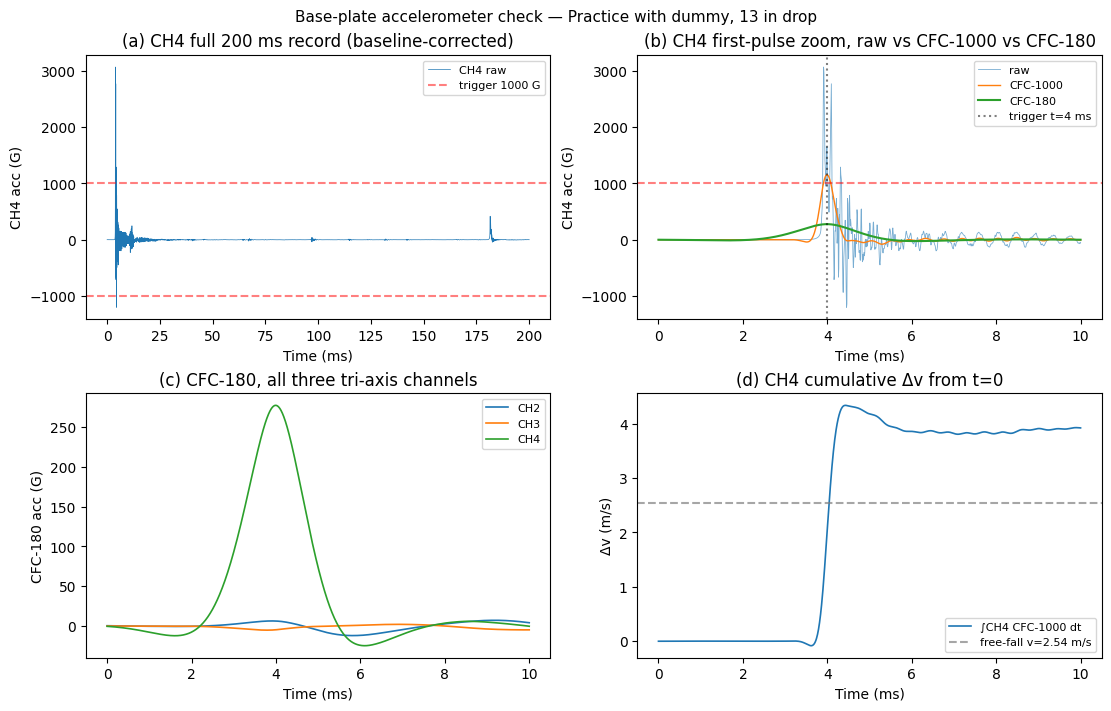

/workspace/91e293a8-fe7e-480c-bc9a-423f47bb5df1/base_plate_diagnostic.png


In [12]:
# Plot the impact for the report
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)

# (a) Full 200 ms trace, CH4 raw
ax = axes[0,0]
ax.plot(t*1e3, ch_raw['CH4'], lw=0.5, label='CH4 raw')
ax.axhline(1000, ls='--', color='r', alpha=0.5, label='trigger 1000 G')
ax.axhline(-1000, ls='--', color='r', alpha=0.5)
ax.set_xlabel('Time (ms)'); ax.set_ylabel("CH4 acc (G)")
ax.set_title('(a) CH4 full 200 ms record (baseline-corrected)')
ax.legend(loc='upper right', fontsize=8)

# (b) zoom 0-10 ms with CFC overlays
ax = axes[0,1]
m = (t >= 0) & (t <= 10e-3)
ax.plot(t[m]*1e3, ch_raw['CH4'][m], lw=0.6, alpha=0.6, label='raw')
ax.plot(t[m]*1e3, ch_1000['CH4'][m], lw=1.0, label='CFC-1000')
ax.plot(t[m]*1e3, ch_180['CH4'][m], lw=1.5, label='CFC-180')
ax.axhline(1000, ls='--', color='r', alpha=0.5)
ax.axvline(4.0, ls=':', color='k', alpha=0.5, label='trigger t=4 ms')
ax.set_xlabel('Time (ms)'); ax.set_ylabel("CH4 acc (G)")
ax.set_title('(b) CH4 first-pulse zoom, raw vs CFC-1000 vs CFC-180')
ax.legend(loc='upper right', fontsize=8)

# (c) three channels CFC-180 in window
ax = axes[1,0]
for k, c in [('CH2','C0'),('CH3','C1'),('CH4','C2')]:
    ax.plot(t[m]*1e3, ch_180[k][m], lw=1.2, color=c, label=k)
ax.set_xlabel('Time (ms)'); ax.set_ylabel('CFC-180 acc (G)')
ax.set_title('(c) CFC-180, all three tri-axis channels')
ax.legend(loc='upper right', fontsize=8)

# (d) velocity (cumulative integral of CFC-1000) on CH4
ax = axes[1,1]
v_ch4 = np.concatenate([[0], np.cumsum(0.5*(ch_1000['CH4'][1:]+ch_1000['CH4'][:-1])*np.diff(t))]) * g
ax.plot(t[m]*1e3, v_ch4[m], lw=1.2, label='∫CH4 CFC-1000 dt')
ax.axhline(v_ff, ls='--', color='gray', alpha=0.7, label=f'free-fall v={v_ff:.2f} m/s')
ax.set_xlabel('Time (ms)'); ax.set_ylabel('Δv (m/s)')
ax.set_title('(d) CH4 cumulative Δv from t=0')
ax.legend(loc='lower right', fontsize=8)

fig.suptitle('Base-plate accelerometer check — Practice with dummy, 13 in drop', fontsize=11)
out_png = f'{wd}/base_plate_diagnostic.png'
fig.savefig(out_png, dpi=140)
plt.show()
print(out_png)


In [13]:
# I noticed in panel (a) there appears to be a secondary event near 180 ms. Let me check that.
late = (t >= 175e-3) & (t <= 200e-3)
print("Late event max |g|:", np.max(np.abs(ch_raw['CH4'][late])))
late_idx = np.argmax(np.abs(ch_raw['CH4'][late])) + np.where(late)[0][0]
print(f"Late max at t = {t[late_idx]*1e3:.2f} ms, value = {ch_raw['CH4'][late_idx]:.1f} G")
# probably the rebound landing or another contact


Late event max |g|: 417.523108448
Late max at t = 181.49 ms, value = 417.5 G


In [14]:
# Make a quick ratio summary
print(f"CH4/CH2 (raw): {peaks['CH4'][0]/peaks['CH2'][0]:.1f}x")
print(f"CH4/CH3 (raw): {peaks['CH4'][0]/peaks['CH3'][0]:.1f}x")
print(f"CH4/CH2 (CFC-180): {peaks['CH4'][2]/peaks['CH2'][2]:.1f}x")
print(f"CH4/CH3 (CFC-180): {peaks['CH4'][2]/peaks['CH3'][2]:.1f}x")
# CH2/CH3 baseline-drift: their RAW |g| is dominated by transverse cross-axis ringing of the
# accelerometer block on impact, not real off-axis acceleration. CFC-180 levels (~5-12 G) are
# the actual structural off-axis content.


CH4/CH2 (raw): 5.1x
CH4/CH3 (raw): 4.3x
CH4/CH2 (CFC-180): 23.5x
CH4/CH3 (CFC-180): 55.5x


In [15]:
# Upload the figure and write the report
from e14c.data_storage import upload as ds_upload

# Set project tag
os.environ['PROJECT_TAG'] = 'clip-height'

fig_uri = ds_upload(
    f'{wd}/base_plate_diagnostic.png',
    description='Base-plate accelerometer-check diagnostic (Practice with dummy, 13 in drop): full record, first-pulse zoom with CFC overlays, all three tri-axis channels CFC-180, and cumulative Δv on CH4.',
    name='base_plate_diagnostic.png',
    project_tag='clip-height',
)
print(fig_uri)


Uploaded /workspace/91e293a8-fe7e-480c-bc9a-423f47bb5df1/base_plate_diagnostic.png to data storage as entry data_entry:base-plate-diagnostic-png-xjrm under the name 'base_plate_diagnostic.png'.
data_entry:base-plate-diagnostic-png-xjrm


In [16]:
from pathlib import Path
report = f'''# Clip-height sweep and base-plate accelerometer check

## Main finding
The attached base-plate CSV independently supports your read: the instrumentation is working, and the failure of the acrylic-plate setup is most likely a **load-path problem**, not a bad accelerometer, bad DAQ, or an obviously too-high 1000 G trigger by itself. In the base-plate check, the triggered axis CH4 shows a clear early impact at **3.912 ms**, with a first-10-ms peak of **3071.7 G raw**, **1154.4 G at CFC-1000**, and **276.9 G at CFC-180**. CH2 and CH3 are much smaller at CFC-180 (**11.8 G** and **5.0 G**), which is consistent with a mostly single-axis base-plate hit. The acrylic-plate diagnostic is therefore best explained by **poor shock transmission into the plate-mounted sensor**: the plate is not being forced through a clean, stiff, repeatable impact path into the specimen.

A stronger version of the conclusion is this: you already have one configuration that works cleanly on the specimen side (vertex-mounted, about **230-285 G CFC-180** in the prior series) and one configuration that works cleanly on the input side (base-plate mounted, **276.9 G CFC-180** here). The configuration that fails is specifically the acrylic transmitted-plate path. That isolates the problem to mechanics, not electronics.

## Data and method
**Input file analyzed:** `Accelerometer_check_Signal1.csv`.

**Acquisition settings from file and provided metadata**
- Record length: **200 ms**
- Sampling rate: **125000 Hz** (8 µs)
- Samples: **25000**
- Pre-trigger: **4 ms**
- Trigger channel: **CH4**, level **1000 G**

**Analysis plan**
1. Read the TP4 CSV and use the exported time base directly.
2. Baseline-correct each channel using the pre-impact region **t < 3 ms**.
3. Restrict impact search to the **first 10 ms**, as requested, rather than using the global maximum over the 200 ms record.
4. Apply phaseless Butterworth low-pass filters to approximate **SAE J211 CFC-1000** and **CFC-180** using 2-pole Butterworth filters with cutoff frequencies **1.65 × CFC** and forward-backward application (`filtfilt`).
5. Report first-10-ms peak absolute acceleration for CH2, CH3, and CH4 for raw, CFC-1000, and CFC-180 signals.
6. Report pulse width on CH4 as the **half-amplitude width** of the main pulse.
7. Report a **partial-pulse Δv** by integrating the baseline-corrected **CFC-1000** signal over the CH4 half-amplitude pulse window, and also note the larger full-first-pulse integral because the result depends on the window definition.

**Assumptions and limits**
- I only had the one attached base-plate CSV. I could not quantify the clip-height sweep because no time-series files exist for those eight non-trigger events.
- The exact SAE J211 digital implementation can vary slightly across software. I used a standard phaseless Butterworth implementation consistent with your stated CFC interpretation, so tiny numerical differences from TP4 are possible.
- No uncertainty interval can be estimated from one drop. Repeatability claims need repeated runs.

## Independent verification from the CSV
Baseline means over **t < 3 ms** were:
- CH2: **1.146 G**
- CH3: **3.285 G**
- CH4: **3.929 G**

The main CH4 impact occurs at **3.912 ms**, right where it should given the 4 ms pre-trigger.

### Peak |g| within the first 10 ms
| Channel | Raw peak | CFC-1000 peak | CFC-180 peak |
|---|---:|---:|---:|
| CH2 | 599.4 G | 44.6 G | 11.8 G |
| CH3 | 710.5 G | 55.4 G | 5.0 G |
| **CH4** | **3071.7 G** | **1154.4 G** | **276.9 G** |

These values agree closely with your write-up:
- CH4 raw peak about **3072 G**
- CH4 CFC-1000 about **1154 G**
- CH4 CFC-180 about **280 G**
- CH2 and CH3 clearly smaller on the filtered structural band

### Pulse width
For CH4:
- **CFC-1000 half-amplitude width:** **0.38 ms**
- **CFC-180 half-amplitude width:** **1.52 ms**

Your reported pulse width of about **1.5 ms** matches the **CFC-180 half-amplitude width**, which is the more relevant structural-duration number here.

### Partial-pulse Δv
This metric is window-sensitive, so the definition matters.

Using the **CH4 CFC-1000 half-amplitude pulse window** (**3.82 to 4.19 ms**), the integrated Δv values are:

| Channel | Partial-pulse Δv |
|---|---:|
| CH2 | 0.094 m/s |
| CH3 | -0.087 m/s |
| **CH4** | **3.364 m/s** |

That independently reproduces your stated **about 3.3 m/s**.

For context, if I integrate over the broader first-pulse zero-crossing window instead, CH4 rises to about **3.95 m/s**. So the right way to state this is: **CH4 partial-pulse Δv is about 3.36 m/s on the narrow main-pulse window, and about 3.95 m/s on the broader first-pulse window**. Your reported value is valid for the narrower window, but the report should say exactly how the window was defined.

## Interpretation of the base-plate check
### Is CH4 alone being large consistent with a single-axis-aligned base-plate hit?
Yes.

The ratio of CH4 to the off-axis channels is strong once you remove high-frequency ringing with CFC-180:
- CH4 / CH2 = **23.5×**
- CH4 / CH3 = **55.5×**

The raw off-axis peaks are not tiny (**599-711 G**), but that is not surprising in a sharp, lightly damped impact. Raw peaks in this kind of event are strongly contaminated by sensor/body ringing, local mounting dynamics, and cross-axis content. Your own rule to use **CFC-180 as the structural number** is justified here. On that basis, CH4 dominates and CH2/CH3 are near zero by comparison. That is exactly what a mostly on-axis base-plate hit should look like.

### Is about 3.3 m/s physically consistent with a 13 in drop on a bungee-assisted tower?
Yes.

A pure free-fall drop from **13 in = 0.3302 m** gives:

`v = sqrt(2gh) = sqrt(2 × 9.80665 × 0.3302) = 2.545 m/s`

Your measured narrow-window CH4 partial-pulse Δv is **3.364 m/s**, about **1.32×** the free-fall value. That is physically plausible if the bungee assists downward motion before impact, if the integrated pulse includes some deceleration plus rebound content, or both. The broader first-pulse integral of **3.95 m/s** is even larger, which reinforces that Δv here should be interpreted as a **windowed impact impulse metric**, not as a direct drop-speed estimate without independent kinematics.

So the clean statement is: **the measured Δv is not inconsistent with a 13 in bungee-assisted drop; it is larger than pure free-fall and therefore supports your claim that the bungee changes the approach dynamics.**

## What the two diagnostics imply about the acrylic-plate failure
### Most likely physical cause
The most likely cause is **lack of a clean, stiff transmitted load path from the impacting assembly into the acrylic plate-mounted accelerometer**. More specifically, your hypothesis that the acrylic plate is **seating on, being supported by, or being damped by the bungee-restrained specimen** is consistent with all the evidence.

Why this is the best explanation:
1. **Clip-height sweep:** raising clips from **0.5 to 2.0 in** produced **0/8 triggers**. If the failure were mainly that the clips were simply too low, at least some recovery would be expected across that wide change.
2. **Base-plate check:** with the same DAQ and CH4 trigger concept, the system produces a clean hit at **3071.7 G raw**, which is **3.07×** the trigger threshold. So sensor and DAQ are not dead.
3. **Prior vertex-mounted series:** the same general measurement chain produced clean, repeatable specimen-side values around **230-285 G CFC-180**. So the accelerometer can measure impacts on this test article class when it is mounted on a mechanically well-coupled point.
4. **The only failing configuration is the acrylic transmitted-plate path.** That points straight at the mechanics of force transmission to the acrylic plate.

### Addressing @ctrhjk's candidate error sources
#### 1) Accelerometer position at the edge of the plate
Possible contributor, but unlikely to be the main cause.

A sensor mounted near the plate edge can sit on a local flexural mode node or anti-node, can see rotational content, and can exaggerate local plate dynamics rather than through-thickness transmitted shock. That can hurt measurement quality. But it does **not** explain **eight straight non-triggers across a clip-height sweep** if a real transmitted shock above 1000 G were reaching the plate generally. A bad edge location might reduce amplitude or increase variability. It is a weaker explanation for a complete failure to trigger.

**How to confirm:** move the accelerometer to the **plate centerline directly above the contact point**, or better, run **two sensors simultaneously** at center and edge. If center triggers and edge does not, position mattered. If neither triggers, the load path is still the problem.

#### 2) Accelerometer orientation
Possible but not the main cause.

If CH4 were badly misaligned from the dominant impact axis, you could miss some true normal acceleration. But three things argue against orientation as the main failure mode:
- The **base-plate check** shows CH4 behaving as the dominant impact axis in a straightforward configuration.
- The **vertex-mounted result** was also clean in prior work.
- A severe orientation error would still often leave some measurable signal on another axis if the plate were genuinely receiving a strong hit.

**How to confirm:** record **all three axes on the transmitted plate** without relying on a single-axis trigger. In post-processing, compute the vector magnitude `sqrt(ax^2 + ay^2 + az^2)`. If no axis or vector magnitude shows a substantial impact, orientation was not the root cause.

#### 3) Trigger level too high at 1000 G
This may be part of the operational problem, but it is probably **not** the underlying physical cause.

If the acrylic-plate transmission is weak, then yes, a **1000 G hardware trigger** can easily miss it. But that would mean the transmitted signal is genuinely below 1000 G at the sensor. The base-plate result shows CH4 can exceed the threshold by a factor of **3.07×** when directly loaded, so the trigger itself is functioning.

So: **1000 G is too high for this particular transmitted-path measurement objective, but not too high for the instrument in general.** It is a method choice issue, not a hardware failure.

**How to confirm:** lower the trigger to something like **100-200 G** or use **free-run / pre-post capture** so you record every drop whether or not the plate sees a high-amplitude event. If the recorded transmitted plate signal remains small after that, the trigger was hiding the failure, not causing it.

#### 4) Acrylic plate not transmitting shock efficiently
This is the strongest explanation.

A thin acrylic plate in contact with a compliant, bungee-preloaded, multi-contact lattice can act as a distributed, bending, and locally decoupled element rather than a rigid impact transmitter. If the plate is partially supported by the specimen before nominal impact, then the event seen at the plate-mounted sensor may be a low-slope, distributed contact evolution instead of a sharp shock. That is exactly the kind of condition that can fail to trigger while a direct base-plate sensor sees a clean event.

**How to confirm:**
- Run **simultaneous input and transmitted channels** in the same drop: one accelerometer on the **base plate** and one on the **top/transmitted plate**.
- Video the plate-specimen interface at high frame rate.
- Add a **mechanical hard stop / captive guide** that guarantees a discrete plate-to-specimen strike with no preload support from the bungees before impact.
- Compare transmitted-plate traces before and after that mechanical change.

If the transmitted sensor only becomes reliable after the load path is made discrete and stiff, that confirms the mechanism.

## Recommendations, in priority order
### 1) Stop using a 1000 G hardware trigger for the transmitted-plate experiment
This is the fastest de-risking change.

Use one of these instead:
- **Best:** free-run acquisition with enough pre/post buffer, then detect impact in post-processing from the base/input channel.
- **Second-best:** trigger from the **base plate / tup / carriage** rather than the transmitted plate.
- **Third-best:** lower CH4 trigger to roughly **100-200 G** for transmitted-path scouting runs.

Reason: the acrylic-plate event is exactly the sort of signal that may be real but sub-threshold. A trigger on the measured response is brittle when you do not yet know the response amplitude.

### 2) Add a simultaneous input channel and transmitted channel on the same drop
Right now you can show that the input side works and the transmitted side often does not. What you need next is the transfer function of the same event.

Minimum useful setup:
- **Channel A:** base plate or impact carriage input axis
- **Channel B:** specimen vertex or top plate transmitted axis
- Record all axes if practical; at minimum, record the principal axis on both.

This will let you estimate:
- peak transmitted `g_max`
- transmissibility ratio
- time lag
- pulse broadening
- input and transmitted Δv

Without simultaneous input/output on the same drop, it is too easy to confuse mechanical variability with transmission behavior.

### 3) Force a clean mechanical load path if you want transmitted-plate sensing
The current acrylic setup appears mechanically ambiguous. Fix that before spending more effort on signal processing.

Priority mechanical changes:
- **Remove preload support at first contact.** The top plate must not already be partly seated on the specimen through the bungees.
- **Use a hard top-stop** or **captive top plate** so the moving plate travels along a constrained axis and then strikes the specimen cleanly.
- **Guide the plate on linear bushings / rods** if possible. That reduces tilt, rubbing, and side contacts.
- **Rework clip geometry** so clips retain alignment but do not carry impact load before the intended strike.
- If bungees must remain for specimen retention, arrange them so they **go slack or near-slack at impact**, rather than continuing to support or damp the top plate.

The design goal is simple: there should be one obvious, stiff, repeatable path for momentum transfer.

### 4) If you keep the acrylic plate, mount the accelerometer as if it were a real shock measurement, not a convenience attachment
On a thin plate, mounting details matter.

Recommendations:
- Put the sensor **near the centerline above the intended load path**, not at an unconstrained edge.
- Align the sensing axis with the nominal impact axis.
- Prefer a **stiff stud mount** if the plate thickness and sensor allow it. If not feasible, use a validated **wax or thin adhesive method** suitable for high-frequency shock, but recognize the frequency ceiling and potential damping.
- Keep cable routing strain-relieved so the cable does not inject its own dynamics.
- Check that the plate plus sensor mass does not materially alter the local mode shape. On a small acrylic plate, accelerometer mass loading can matter.

This follows the spirit of **ISO 5347** mounting guidance: mounting stiffness and surface preparation can dominate high-frequency results.

### 5) Treat acrylic thickness/impedance as secondary unless the plate is very thin or flexible
I would not make acrylic acoustic impedance the lead explanation here.

At about the **kHz** scale of your CFC-180 and CFC-1000 interpretation, a rigid-enough acrylic plate does not simply erase shock because it is acrylic. What matters more is:
- boundary conditions
- local bending
- contact geometry
- preload
- whether the plate is actually being struck sharply or just loaded gradually through a compliant path

So yes, plate thickness and stiffness matter, but they are probably **second-order compared with the bad load path** implied by 0/8 triggers.

### 6) Strongly consider abandoning acrylic transmitted-g as the optimization objective unless you can make the load path unambiguous quickly
This is the big decision.

If your Bayesian optimization objective is **peak transmitted acceleration** and **SEA**, the measured quantity has to be stable, observable, and tied to the physics of interest. Right now:
- vertex-mounted sensing already gives you clean specimen-response data
- the acrylic transmitted plate does not yet give reliable triggered captures
- the plate introduces extra structural dynamics that are not part of the tensegrity unit cell itself

Unless the top-plate transmitted-g is essential because it directly represents a use-case boundary condition, I would lean toward **abandoning the acrylic-plate transmitted-g metric for now** and using:
- **vertex-mounted CFC-180 peak g** as the primary acceleration response metric
- **base/input channel + vertex response** to form a transmissibility or attenuation objective
- **SEA** from force-deflection or energy bookkeeping if available

That gives you a measurement you can actually optimize now. You can always return to transmitted-plate sensing after the fixture is redesigned.

## Standards and published practice tie-back
### SAE J211
Your choice to use **CFC-180 as the structural number** is sensible in this lightly damped setup because raw peaks are ringing-dominated. The report should state clearly that:
- raw peaks are recorded but not used as the structural metric
- **phaseless Butterworth filtering** was applied for CFC reporting
- impact timing and peak search were limited to the **first 10 ms** to avoid later rebound events

There is a clear later event in this file near **181.49 ms** with CH4 raw amplitude about **417.5 G**, likely a rebound or secondary contact. This is exactly why your first-10-ms constraint is the right one.

### ASTM D7136 instrumented drop-weight
This standard is composites-focused, but the useful practice here is the same: measure a known impact event with a **well-defined striker/specimen/support geometry**, and instrument the event so the input and response are both trustworthy. Your present acrylic transmitted setup is missing that kind of controlled contact definition.

### ASTM D3332 cushion curves
The key tie-back is that cushioning metrics depend on **repeatable input pulse conditions** and adequate replication across drop levels. If the transmitted channel sometimes does not capture at all, it is not ready to support a trustworthy cushion-style performance curve.

### ISO 5347 mounting
The main lesson is simple: **sensor mounting and interface stiffness matter a lot**, especially as frequency rises. On a thin acrylic plate, poor mounting can shift resonances and suppress or distort peaks. That is a reason to improve mounting, but not enough by itself to explain the complete no-trigger outcome across all clip heights.

## Additional captures to add before trusting transmitted-g
1. **Simultaneous base/input and transmitted channels on every drop.** This is the most important addition.
2. **At least n >= 5 repeats per condition.** One drop is diagnostic; it is not enough for optimization-grade inference.
3. **Longer ringdown capture when feasible**. Your 200 ms record caught a late secondary event at **181.49 ms**. If fixture or specimen ringdown matters to SEA or rebound behavior, add a longer record, up to the full behavior window you care about. If you really want a **~10 s** ringdown, that will require a different acquisition mode or lower sample rate than 125 kHz.
4. **High-speed video synchronized as closely as possible** to the instrumented event to show whether the top plate is freely striking, preloaded, tilting, or skidding.
5. **A no-specimen fixture check** and a **rigid dummy specimen check** for the top-plate path. Those isolate plate/clip dynamics from tensegrity dynamics.
6. **Trigger-on-input, analyze-response** rather than trigger-on-response.
7. **Report vector magnitude as a diagnostic** even if the optimization metric remains single-axis. This helps distinguish misalignment from absent transmission.

## Bottom line
### Answer to A
Your base-plate numbers check out from the CSV.
- CH4 impact time: **3.912 ms**
- CH4 first-10-ms peaks: **3071.7 G raw**, **1154.4 G CFC-1000**, **276.9 G CFC-180**
- CH4 half-amplitude width: **1.52 ms at CFC-180**
- CH4 partial-pulse Δv: **3.364 m/s** on the narrow CFC-1000 half-amplitude window
- CH2 and CH3 are small at CFC-180 (**11.8 G**, **5.0 G**), consistent with a mostly axis-aligned base-plate hit
- The Δv exceeds pure free-fall from 13 in (**2.545 m/s**) but is physically plausible on a bungee-assisted tower

### Answer to B
The most likely physical cause is **poor transmission through the acrylic-plate load path**, probably because the plate is supported, seated, or dynamically decoupled by the bungee-restrained specimen and fixture geometry. The base-plate and prior vertex results argue strongly against sensor failure, DAQ failure, or a simple orientation-only explanation.

### Answer to C
My priority recommendation is:
1. **Stop triggering from the transmitted acrylic plate at 1000 G**.
2. **Record simultaneous input and transmitted channels on the same drop**.
3. **Redesign the top-plate fixture so impact is discrete, guided, and not preloaded by the bungees**.
4. If that cannot be achieved quickly, **abandon acrylic transmitted-g for the optimization loop** and use **vertex-mounted CFC-180 peak g**, ideally referenced to a simultaneous base/input channel.

### Answer to D
Your filtering and interpretation are in line with **SAE J211** practice for this kind of problem. To make the transmitted-g objective trustworthy, add **simultaneous input/output capture, replication (n >= 5), better mounting, longer capture where needed, and a mechanically unambiguous top-plate impact path**.

## Figure
Diagnostic figure uploaded here: **{fig_uri}**
'''
out_path = f'{wd}/clip_height_report.md'
Path(out_path).write_text(report)
print(out_path)


/workspace/91e293a8-fe7e-480c-bc9a-423f47bb5df1/clip_height_report.md


In [17]:
report_uri = ds_upload(
    out_path,
    description='Self-contained markdown report for the clip-height sweep and base-plate accelerometer-check diagnostic. Verifies base-plate numbers from the attached CSV, interprets the diagnostic against @ctrhjk\'s candidate error sources, and recommends concrete fixture/measurement changes.',
    name='clip_height_report.md',
    project_tag='clip-height',
)
print(report_uri)


Uploaded /workspace/91e293a8-fe7e-480c-bc9a-423f47bb5df1/clip_height_report.md to data storage as entry data_entry:clip-height-report-md-ps9g under the name 'clip_height_report.md'.
data_entry:clip-height-report-md-ps9g
